In [175]:
import os

In [299]:
with open("att_fracface.csv", "w") as f:
    f.write("img_path\n")
    for fn in os.listdir("../attributes_fracface/gen"):
        f.write("../attributes_fracface/gen_" + fn + "\n")
    for fn in os.listdir("../attributes_fracface/in"):
        f.write("../attributes_fracface/in_" + fn + "\n")


In [300]:
import os, shutil
for fn in os.listdir("../attributes_fracface/gen"):
    shutil.move("../attributes_fracface/gen/" + fn, "../attributes_fracface/gen_" + fn)

In [301]:
import os, shutil
for fn in os.listdir("../attributes_fracface/in"):
    shutil.move("../attributes_fracface/in/" + fn, "../attributes_fracface/in_" + fn)

In [298]:
fn

'00004.png'

In [331]:
import pandas as pd
df = pd.read_csv("test_outputs.csv")

In [332]:
generated = {}
input = {}

In [333]:
import json
data = df.T.to_json()
data = json.loads(data)

In [334]:
for i in data.values():
    name = i["face_name_align"].split("/")[-1].replace("in_", "").replace("gen_", "").replace("in", "")
    if "gen_" in i["face_name_align"]:
        generated[name] = {
            "age": i["age"],
            "race": i["race"],
            "gender": i["gender"],
        }
    else:
        input[name] = {
            "age": i["age"],
            "race": i["race"],
            "gender": i["gender"],
        }

In [335]:
# from datasets import load_dataset

# ds = load_dataset("HuggingFaceM4/FairFace", "0.25")

In [336]:
# ds = ds["train"]

In [337]:
# ds = ds.to_list()[:100]

In [338]:
# import random
# random.seed(42)
# # random.shuffle(ds)

In [339]:
age_label = ["0-2", "3-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
gender_label = ["Male", "Female"]
race_label = ["East Asian", "Indian", "Black", "White", "Middle Eastern", "Latino_Hispanic", "Southeast Asian"]

In [340]:
generated[sorted(input.keys())[38]], race_label[ds[38]["race"]]

({'age': '20-29', 'race': 'Black', 'gender': 'Female'}, 'Black')

In [341]:
age_pred = []
age_gt = []
race_pred = []
race_gt = []
gender_pred = []
gender_gt = []
for i, filename in enumerate(sorted(input.keys())):
    gen = generated[filename]
    inp = input[filename]
    age_pred.append(gen["age"])
    age_gt.append(inp["age"])
    # age_gt.append(age_label[ds[i]["age"]])
    race_pred.append(gen["race"])
    race_gt.append(inp["race"])
    # race_gt.append(race_label[ds[i]["race"]])
    gender_pred.append(gen["gender"])
    gender_gt.append(inp["gender"])
    # gender_gt.append(gender_label[ds[i]["gender"]])

In [342]:
import pylab
# calculate F1 score weighted and mean_absolute_error for age
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, r2_score
print("FracFace")
print("Age MAE:", mean_absolute_error([int(i.replace("+", "").split("-")[0]) + 5 for i in age_gt], [int(i.replace("+", "").split("-")[0]) + 5 for i in age_pred]))
print("Race F1:", f1_score(race_gt, race_pred, average="weighted"))
print("Gender F1:", f1_score(gender_gt, gender_pred, average="weighted"))

print("Race Acc:", accuracy_score(race_gt, race_pred))
print("Gender Acc:", accuracy_score(gender_gt, gender_pred))


FracFace
Age MAE: 6.02
Race F1: 0.55239898989899
Gender F1: 0.7701152882205514
Race Acc: 0.56
Gender Acc: 0.77


In [343]:
# age spearman coorelation
from scipy.stats import spearmanr
age_gt_num = [int(i.replace("+", "").split("-")[0]) + 5 for i in age_gt]
age_pred_num = [int(i.replace("+", "").split("-")[0]) + 5 for i in age_pred]
corr, _ = spearmanr(age_gt_num, age_pred_num)
print("Age Spearman Correlation:", corr)

Age Spearman Correlation: 0.7372050131646398


In [344]:
import numpy as np
from PIL import Image

def vstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = max([img.size[0] for img in images])
    height = sum([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    y_pos = 0
    for img in images:
        stacked.paste(img, (0, y_pos))
        y_pos += img.size[1]
    return stacked


def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

{'age': '10-19', 'race': 'Southeast Asian', 'gender': 'Female'}
{'age': '20-29', 'race': 'Southeast Asian', 'gender': 'Female'}


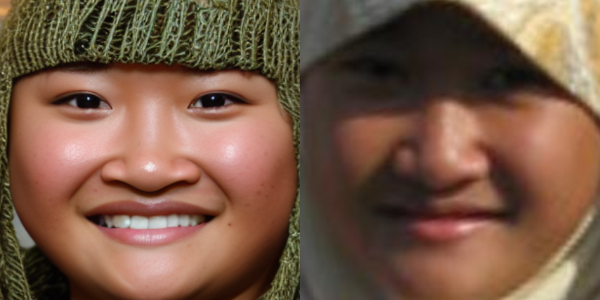

In [345]:
idx = 0
keys = sorted(list(input.keys()))
print(generated[keys[idx]])
print(input[keys[idx]])
hstack(
    [Image.open("./detected_faces/gen_" + keys[idx]), Image.open("./detected_faces/in_" + keys[idx])]
)